# 0. Import Libraries 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

NOTEBOOK_DIR = Path().resolve()
BASE_DIR = NOTEBOOK_DIR.parents[2]

DATA_PROCESSED  = BASE_DIR / 'data/processed/'
OUTPUT_FIGURES  = BASE_DIR / 'outputs/figures/eda/'
OUTPUT_REPORTS  = BASE_DIR / 'outputs/reports/'

OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)
OUTPUT_REPORTS.mkdir(parents=True, exist_ok=True)

print('Libraries loaded.')
print(f'BASE_DIR       : {BASE_DIR}')
print(f'DATA_PROCESSED : {DATA_PROCESSED}')


Libraries loaded.
BASE_DIR       : C:\Data Codingan\student_stress_data_science
DATA_PROCESSED : C:\Data Codingan\student_stress_data_science\data\processed


# 1. Load Data and Merge 

In [3]:
daily_activities   = pd.read_csv(DATA_PROCESSED / 'daily_activities_clean.csv')
stress_predictions = pd.read_csv(DATA_PROCESSED / 'stress_predictions_clean.csv')

In [4]:
# Inner join sesuai dokumen rencana EDA
daily_eda = daily_activities.merge(
    stress_predictions[['activity_id', 'stress_score', 'stress_level']],
    left_on='id',
    right_on='activity_id',
    how='inner'
)

print(f'daily_eda shape setelah merge: {daily_eda.shape}')
daily_eda.head(3)

daily_eda shape setelah merge: (26579, 21)


,id,user_id,activity_date,sleep_hours,study_hours,screen_time_hours,social_media_hours,physical_activity_minutes,caffeine_intake_mg,mood_score,...,assignment_load,deadline_pressure,social_interaction_score,financial_worry_score,health_condition_score,created_at,updated_at,activity_id,stress_score,stress_level
0,1,1,2026-01-01,7.23,1.93,5.78,3.81,13,160,4,...,5,4,6,2,5,2026-01-01 22:45:00,2026-01-01 23:39:00,1,49.60,Medium
1,2,1,2026-01-02,7.10,2.70,7.88,3.78,21,105,6,...,9,6,4,5,4,2026-01-02 19:44:00,2026-01-02 20:40:00,2,49.54,Medium
2,3,1,2026-01-03,6.56,3.24,8.65,4.78,23,123,6,...,5,5,8,2,6,2026-01-03 20:28:00,2026-01-03 20:33:00,3,50.63,Medium


In [5]:
# Kolom fitur yang dipakai untuk analisis
FEATURE_COLS = [
    'sleep_hours', 'study_hours', 'screen_time_hours', 'social_media_hours',
    'physical_activity_minutes', 'caffeine_intake_mg',
    'mood_score', 'fatigue_level', 'assignment_load', 'deadline_pressure',
    'social_interaction_score', 'financial_worry_score', 'health_condition_score'
]

# Urutan stress_level untuk plotting
STRESS_ORDER = ['Low', 'Medium', 'High']
STRESS_PALETTE = {'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'}

print('Feature columns:', FEATURE_COLS)
print('\nstress_level distribution:')
print(daily_eda['stress_level'].value_counts())

Feature columns: ['sleep_hours', 'study_hours', 'screen_time_hours', 'social_media_hours', 'physical_activity_minutes', 'caffeine_intake_mg', 'mood_score', 'fatigue_level', 'assignment_load', 'deadline_pressure', 'social_interaction_score', 'financial_worry_score', 'health_condition_score']

stress_level distribution:
stress_level
Medium    23256
High       2583
Low         740
Name: count, dtype: int64


# 2. Distribusi Target: `stress_level` dan `stress_score`

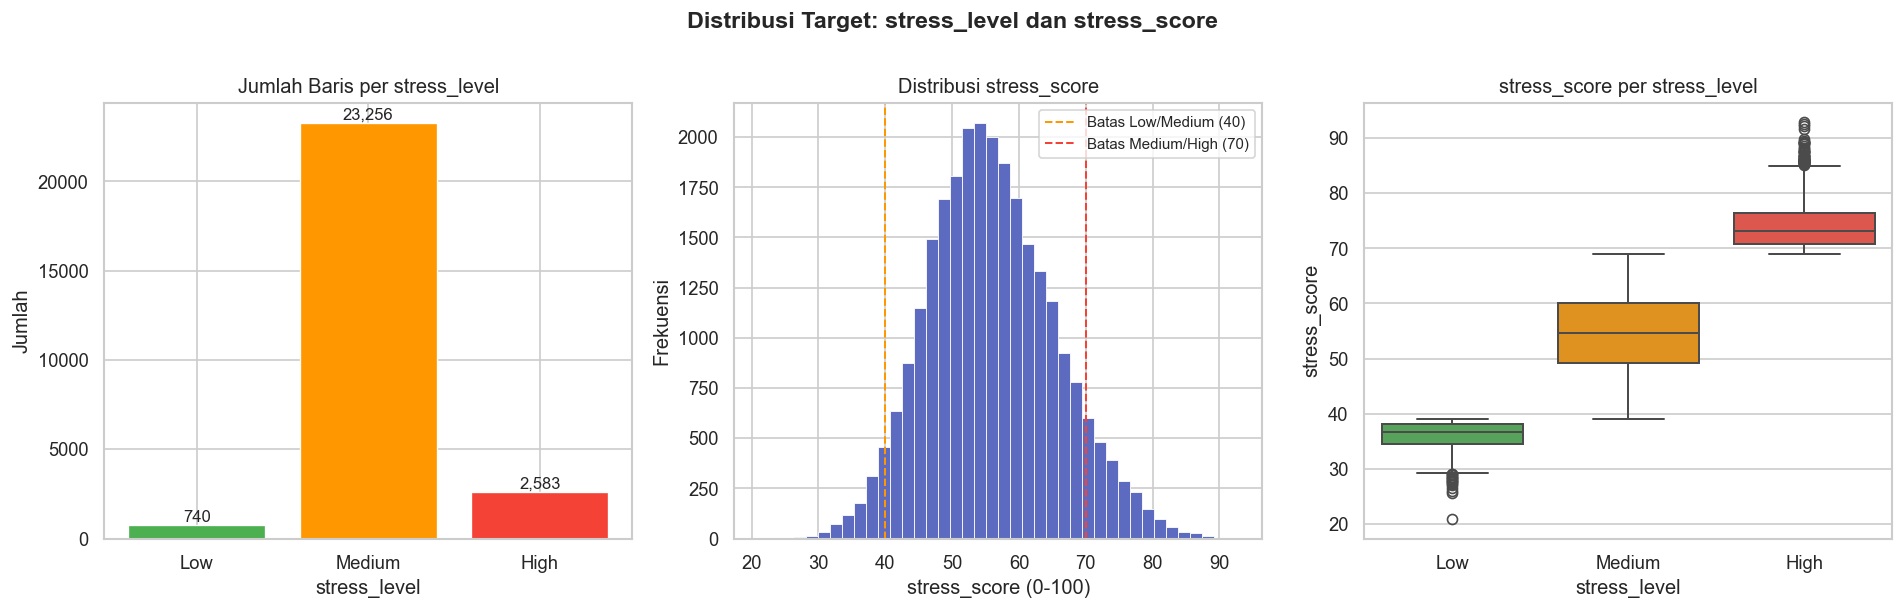


--- Summary Distribusi Target ---
Low     :    740 baris (2.8%)
Medium  : 23,256 baris (87.5%)
High    :  2,583 baris (9.7%)


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribusi Target: stress_level dan stress_score', fontsize=14, fontweight='bold', y=1.01)

# --- Plot 1: Bar chart stress_level ---
level_counts = daily_eda['stress_level'].value_counts().reindex(STRESS_ORDER)
bars = axes[0].bar(level_counts.index, level_counts.values,
                   color=[STRESS_PALETTE[l] for l in level_counts.index], edgecolor='white', linewidth=0.8)
axes[0].set_title('Jumlah Baris per stress_level')
axes[0].set_xlabel('stress_level')
axes[0].set_ylabel('Jumlah')
for bar, val in zip(bars, level_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontsize=10)

# --- Plot 2: Histogram stress_score ---
axes[1].hist(daily_eda['stress_score'], bins=40, color='#5C6BC0', edgecolor='white', linewidth=0.5)
axes[1].set_title('Distribusi stress_score')
axes[1].set_xlabel('stress_score (0-100)')
axes[1].set_ylabel('Frekuensi')
axes[1].axvline(40, color='#FF9800', linestyle='--', linewidth=1.2, label='Batas Low/Medium (40)')
axes[1].axvline(70, color='#F44336', linestyle='--', linewidth=1.2, label='Batas Medium/High (70)')
axes[1].legend(fontsize=9)

# --- Plot 3: Boxplot stress_score by stress_level ---
sns.boxplot(data=daily_eda, x='stress_level', y='stress_score', order=STRESS_ORDER,
            palette=STRESS_PALETTE, ax=axes[2], linewidth=1.2)
axes[2].set_title('stress_score per stress_level')
axes[2].set_xlabel('stress_level')
axes[2].set_ylabel('stress_score')

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / '01_target_distribution.png', bbox_inches='tight')
plt.show()

# Summary
print('\n--- Summary Distribusi Target ---')
total = len(daily_eda)
for level in STRESS_ORDER:
    n = level_counts[level]
    print(f'{level:8s}: {n:6,} baris ({n/total*100:.1f}%)')

## Insight
- Dataset sangat imbalanced. Medium mendominasi 87.5% (23.256 baris), High hanya 9.7% (2.583 baris), dan Low sangat sedikit yaitu 2.8% (740 baris). Ini bukan distribusi yang sehat untuk modelling.
- Karena kelas Low sangat minoritas, model berpotensi mengabaikan kelas ini saat training. Gunakan F1-macro atau weighted sebagai metrik utama, dan pertimbangkan class_weight='balanced' di model baseline.
- Perlu dicatat ke notebook 04, apakah perlu resampling (oversampling Low, undersampling Medium) sebelum modelling, atau cukup dengan class_weight adjustment.

# 3. Distribusi Fitur Aktivitas Harian 

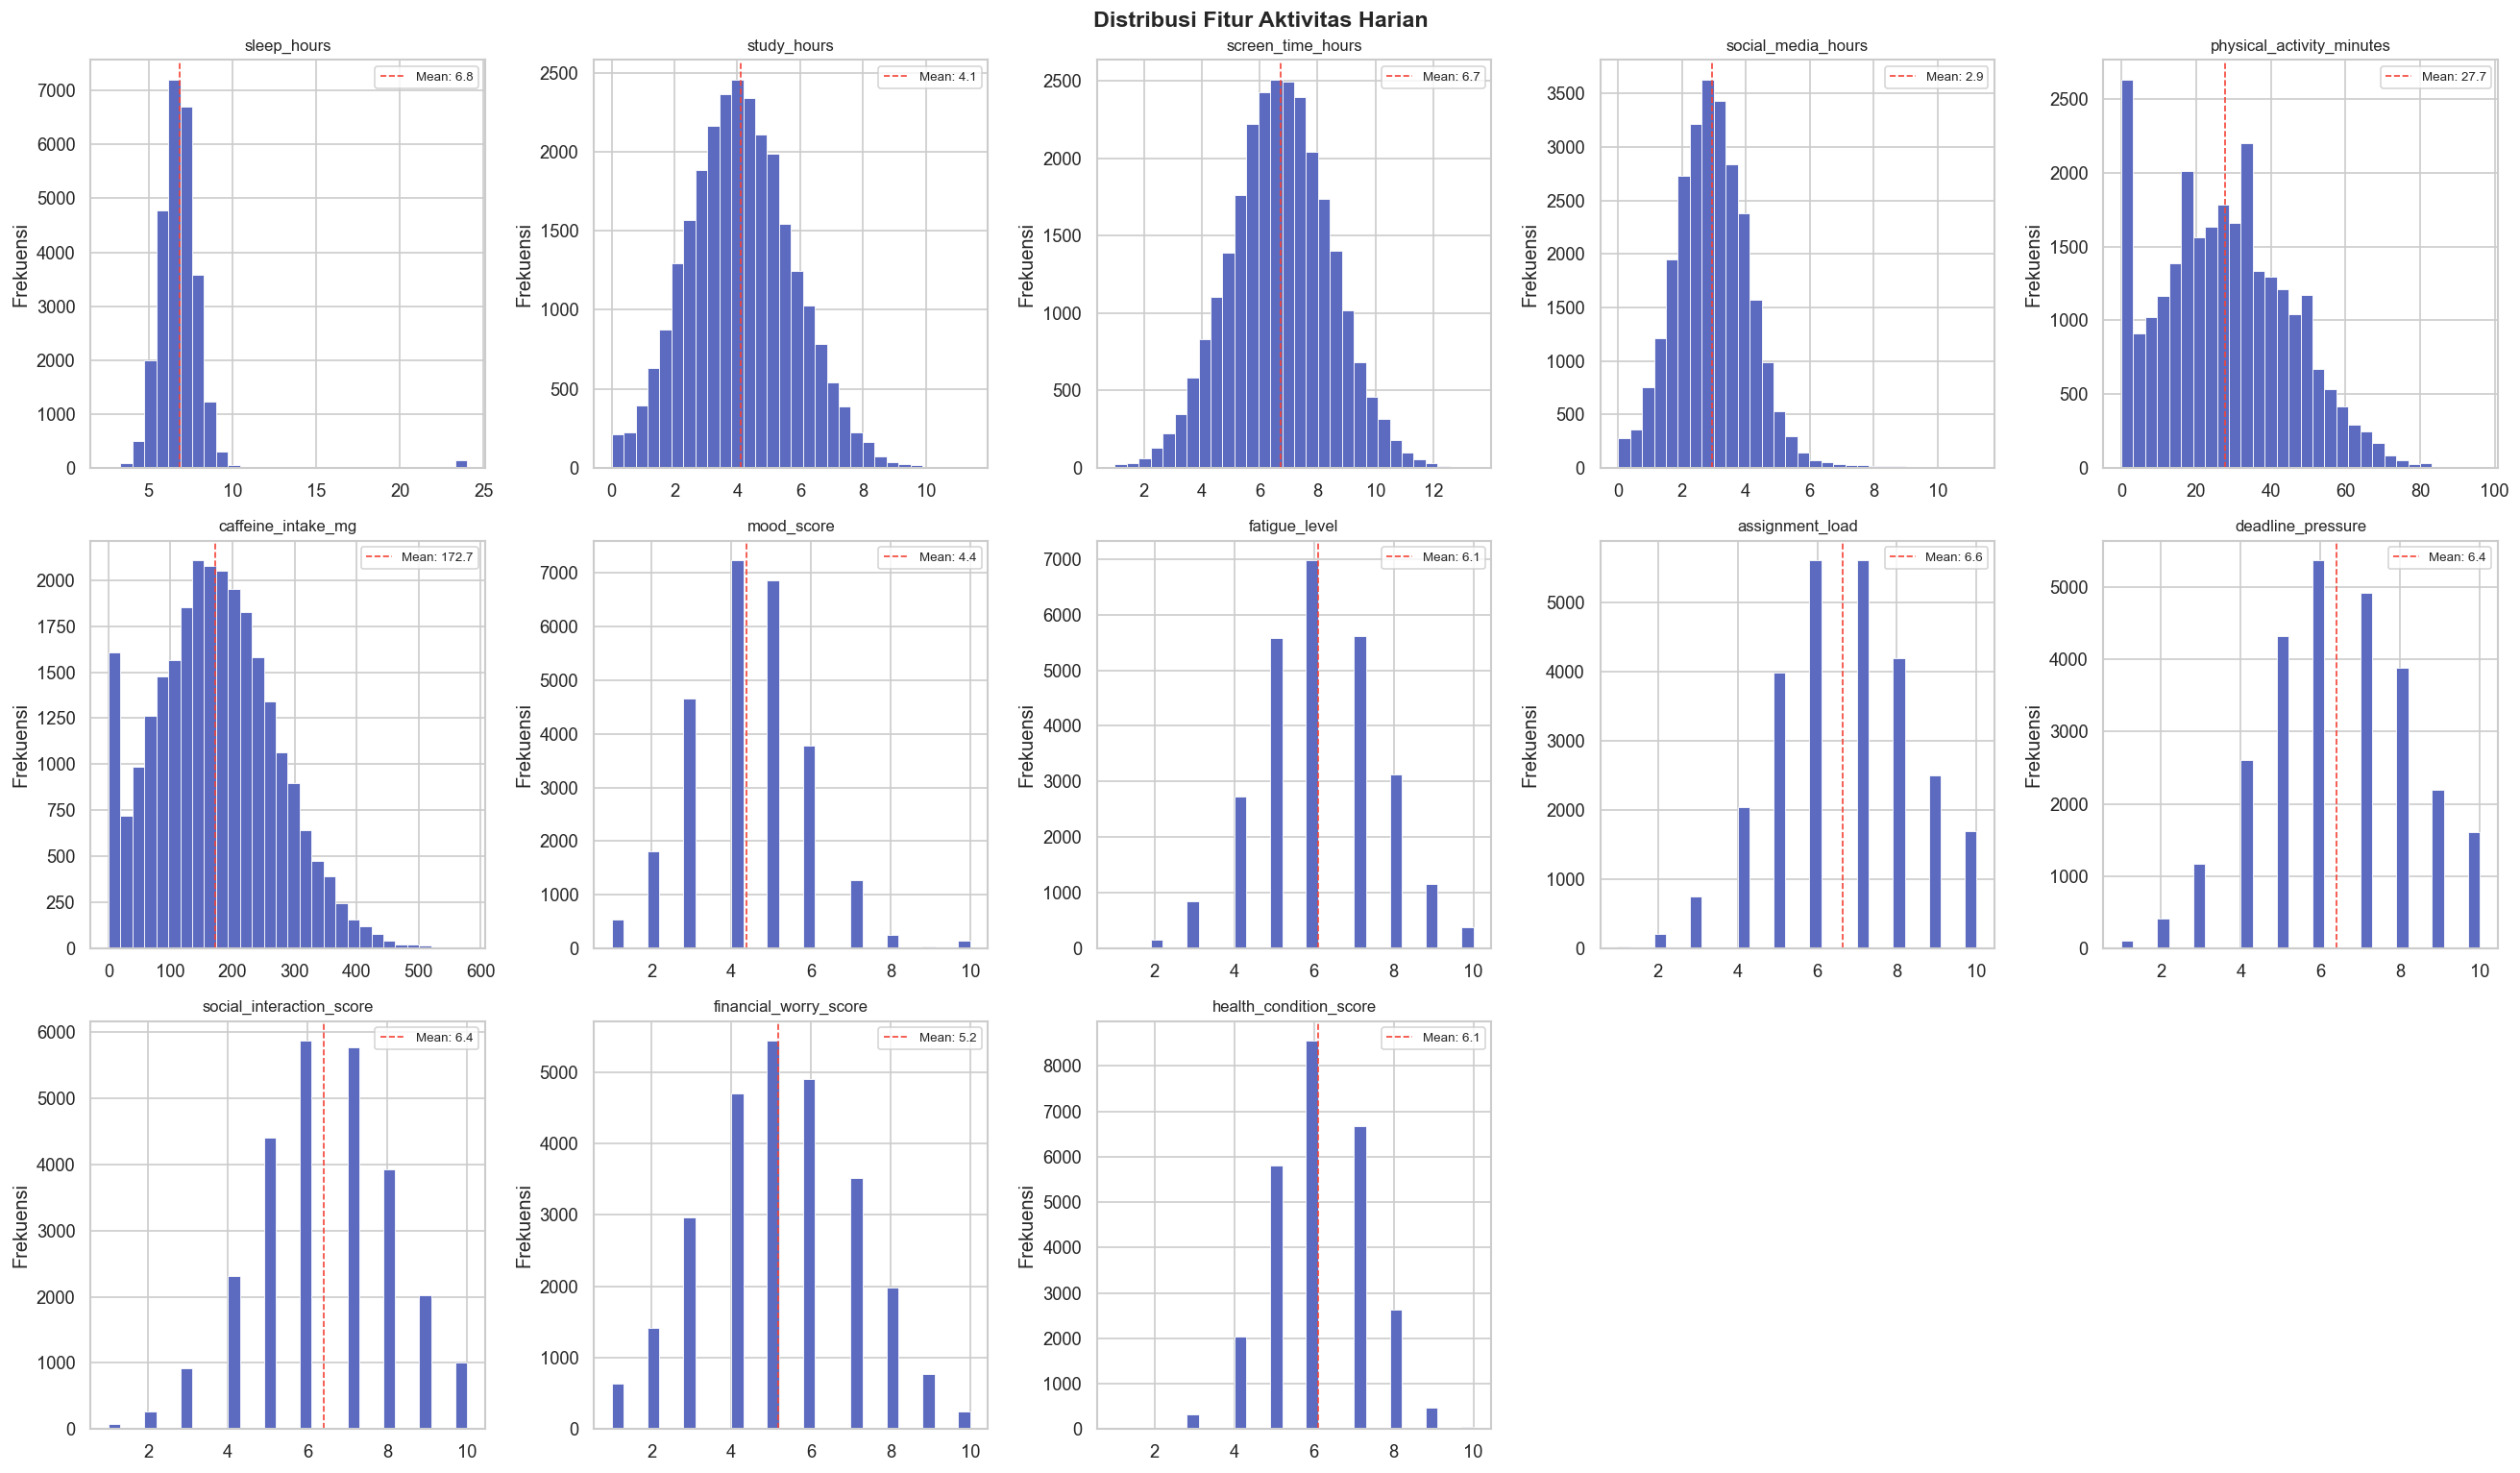


--- Statistik Deskriptif Fitur ---


,sleep_hours,study_hours,screen_time_hours,social_media_hours,physical_activity_minutes,caffeine_intake_mg,mood_score,fatigue_level,assignment_load,deadline_pressure,social_interaction_score,financial_worry_score,health_condition_score
count,26579.00,26579.00,26579.00,26579.00,26579.00,26579.00,26579.00,26579.00,26579.00,26579.0,26579.00,26579.00,26579.00
mean,6.83,4.11,6.71,2.95,27.73,172.68,4.39,6.10,6.64,6.4,6.40,5.18,6.10
std,1.57,1.66,1.72,1.18,17.38,95.74,1.45,1.52,1.78,1.9,1.73,1.88,1.22
min,2.60,0.00,1.00,0.00,0.00,0.00,1.00,1.00,1.00,1.0,1.00,1.00,1.00
25%,6.08,2.96,5.57,2.17,15.00,104.00,3.00,5.00,5.00,5.0,5.00,4.00,5.00
50%,6.76,4.06,6.72,2.91,27.00,170.00,4.00,6.00,7.00,6.0,6.00,5.00,6.00
75%,7.42,5.21,7.88,3.67,40.00,237.00,5.00,7.00,8.00,8.0,8.00,6.00,7.00
max,24.00,11.41,13.38,11.22,96.00,578.00,10.00,10.00,10.00,10.0,10.00,10.00,10.00


In [7]:
fig, axes = plt.subplots(3, 5, figsize=(22, 13))
axes = axes.flatten()
fig.suptitle('Distribusi Fitur Aktivitas Harian', fontsize=14, fontweight='bold')

for i, col in enumerate(FEATURE_COLS):
    axes[i].hist(daily_eda[col], bins=30, color='#5C6BC0', edgecolor='white', linewidth=0.5)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frekuensi')
    mean_val = daily_eda[col].mean()
    axes[i].axvline(mean_val, color='#F44336', linestyle='--', linewidth=1, label=f'Mean: {mean_val:.1f}')
    axes[i].legend(fontsize=8)

# Hapus axes kosong
for j in range(len(FEATURE_COLS), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / '02_feature_distributions.png', bbox_inches='tight')
plt.show()

print('\n--- Statistik Deskriptif Fitur ---')
daily_eda[FEATURE_COLS].describe().round(2)

## Insight
- sleep_hours rata-rata 6.83 jam dengan std 1.57, mayoritas mahasiswa tidur cukup, tapi ada outlier ekstrem di 24 jam.
- fatigue_level dan deadline_pressure memiliki rata-rata tinggi (6.1 dan 6.4 dari skala 10), ini wajar karena data mensimulasikan kondisi mahasiswa aktif.
- caffeine_intake_mg memiliki max 578 mg yang jauh di atas threshold risiko (350 mg), ini outlier valid karena bisa terjadi saat minggu ujian, tapi perlu dicatat.
- social_media_hours rata-rata hanya 2.95 jam dengan max 11.22, distribusinya relatif normal tapi ada ekor kanan yang panjang.
- physical_activity_minutes rata-rata 27.73 menit, artinya secara umum mahasiswa dalam dataset ini cukup aktif secara fisik di atas threshold risiko (15 menit).

# 4. Perbandingan Fitur Berdasarkan `stress_level`

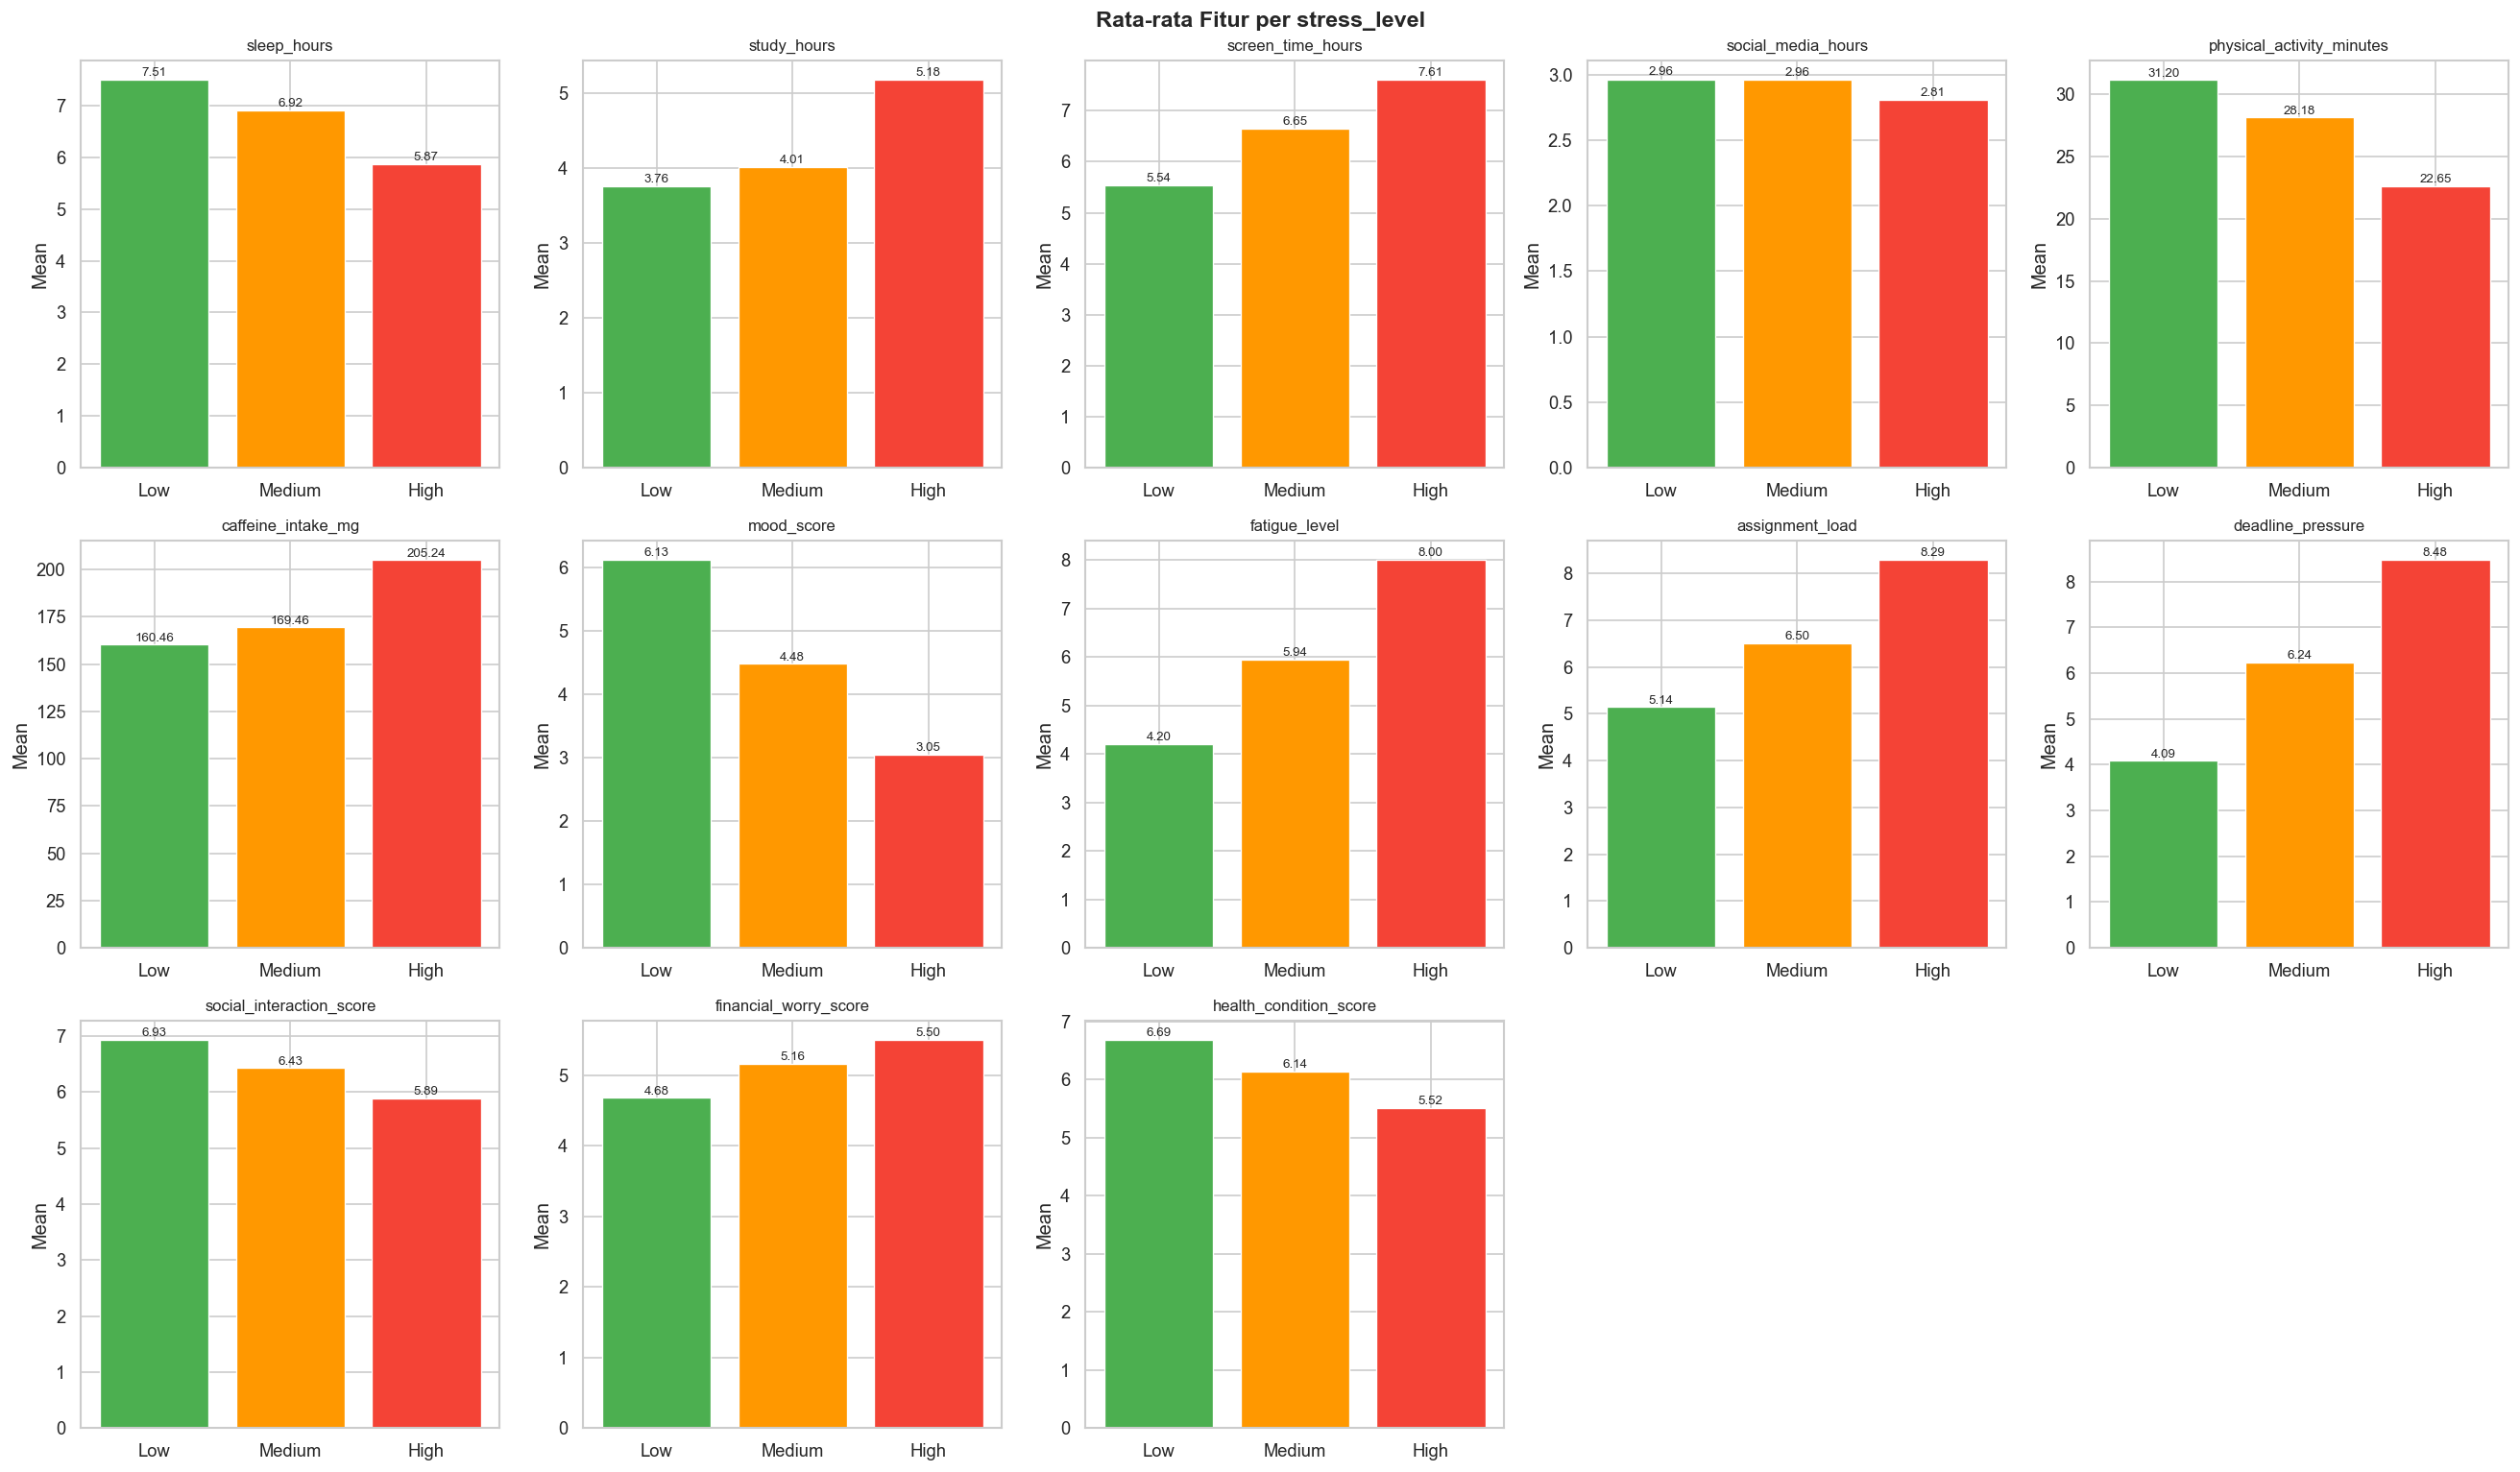


--- Tabel Rata-rata Fitur per stress_level ---


stress_level,Low,Medium,High
sleep_hours,7.51,6.92,5.87
study_hours,3.76,4.01,5.18
screen_time_hours,5.54,6.65,7.61
social_media_hours,2.96,2.96,2.81
physical_activity_minutes,31.20,28.18,22.65
caffeine_intake_mg,160.46,169.46,205.24
mood_score,6.13,4.48,3.05
fatigue_level,4.20,5.94,8.00
assignment_load,5.14,6.50,8.29
deadline_pressure,4.09,6.24,8.48


In [8]:
# 4.1 Mean barplot semua fitur per stress_level
mean_by_level = daily_eda.groupby('stress_level')[FEATURE_COLS].mean().reindex(STRESS_ORDER)

fig, axes = plt.subplots(3, 5, figsize=(22, 13))
axes = axes.flatten()
fig.suptitle('Rata-rata Fitur per stress_level', fontsize=14, fontweight='bold')

for i, col in enumerate(FEATURE_COLS):
    vals = mean_by_level[col]
    bars = axes[i].bar(vals.index, vals.values,
                       color=[STRESS_PALETTE[l] for l in vals.index],
                       edgecolor='white', linewidth=0.8)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Mean')
    for bar, v in zip(bars, vals.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{v:.2f}', ha='center', va='bottom', fontsize=8)

for j in range(len(FEATURE_COLS), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / '03_mean_feature_by_stress_level.png', bbox_inches='tight')
plt.show()

print('\n--- Tabel Rata-rata Fitur per stress_level ---')
mean_by_level.T.round(2)

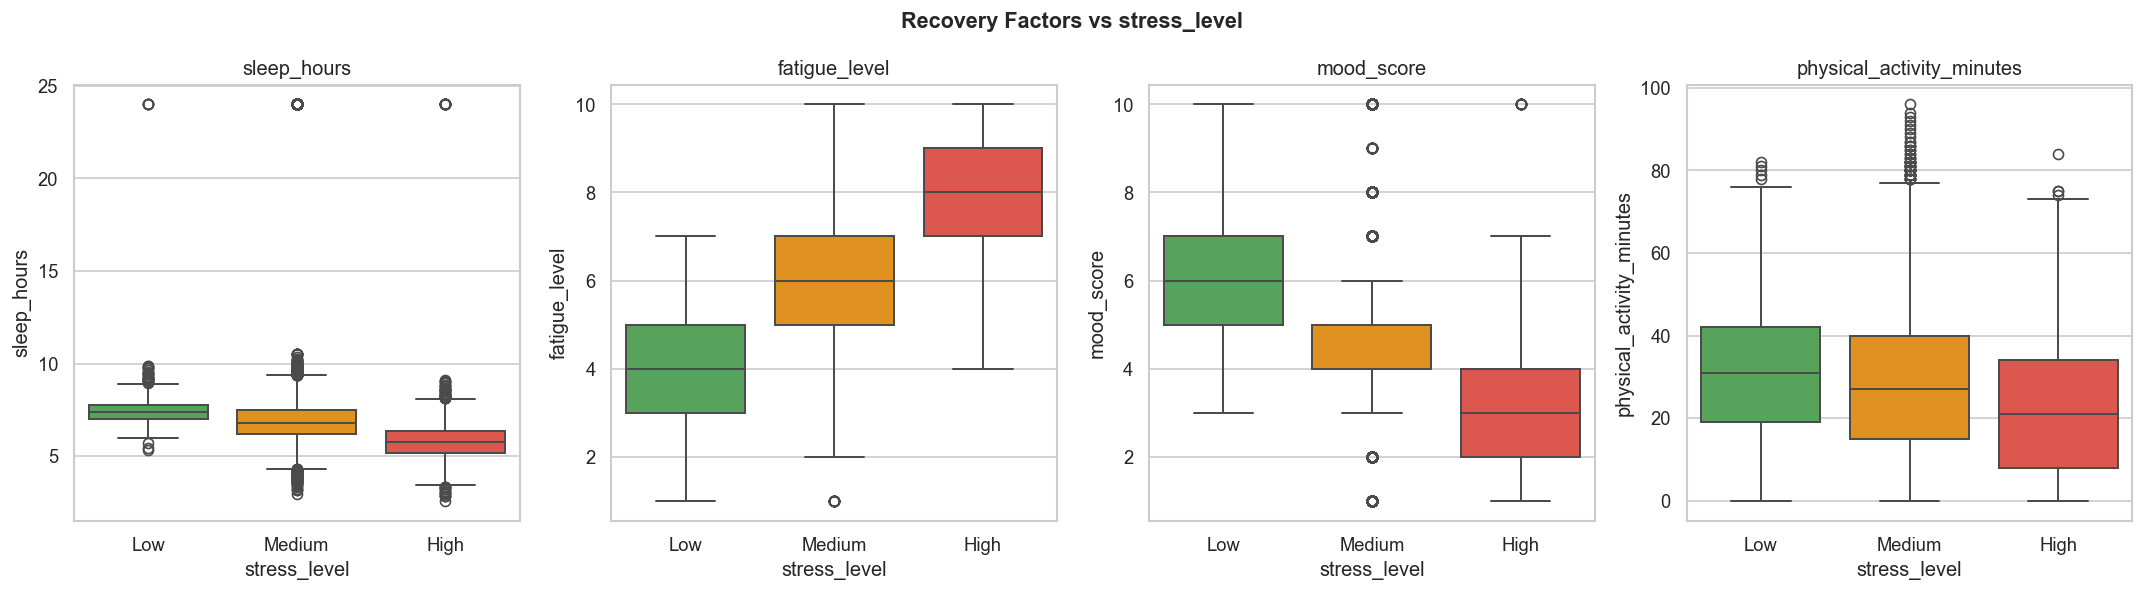

In [9]:
# 4.2 Kelompok Analisis: Recovery Factors
recovery_features = ['sleep_hours', 'fatigue_level', 'mood_score', 'physical_activity_minutes']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Recovery Factors vs stress_level', fontsize=13, fontweight='bold')

for i, col in enumerate(recovery_features):
    sns.boxplot(data=daily_eda, x='stress_level', y=col, order=STRESS_ORDER,
                palette=STRESS_PALETTE, ax=axes[i], linewidth=1.2)
    axes[i].set_title(col)
    axes[i].set_xlabel('stress_level')

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / '04_recovery_factors_boxplot.png', bbox_inches='tight')
plt.show()

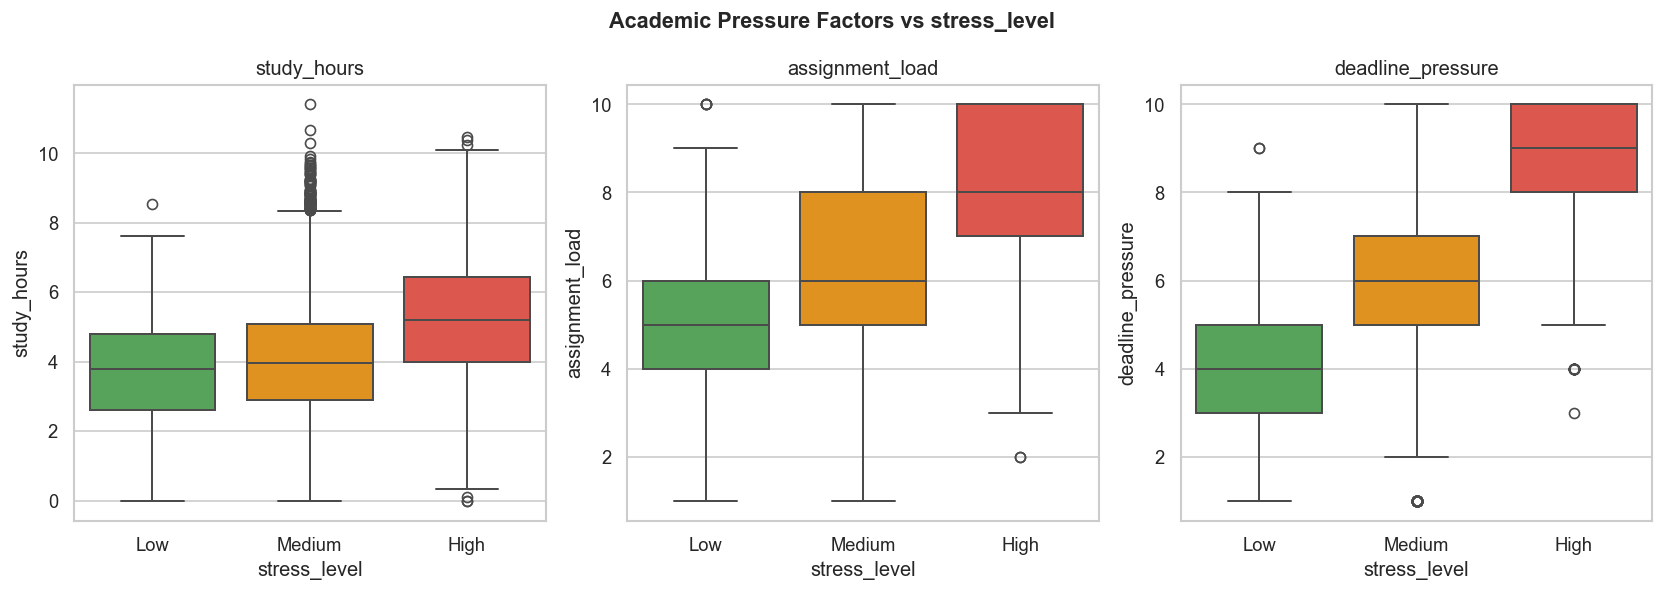

In [10]:
# 4.3 Kelompok Analisis: Academic Pressure Factors
academic_features = ['study_hours', 'assignment_load', 'deadline_pressure']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Academic Pressure Factors vs stress_level', fontsize=13, fontweight='bold')

for i, col in enumerate(academic_features):
    sns.boxplot(data=daily_eda, x='stress_level', y=col, order=STRESS_ORDER,
                palette=STRESS_PALETTE, ax=axes[i], linewidth=1.2)
    axes[i].set_title(col)
    axes[i].set_xlabel('stress_level')

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / '05_academic_pressure_boxplot.png', bbox_inches='tight')
plt.show()

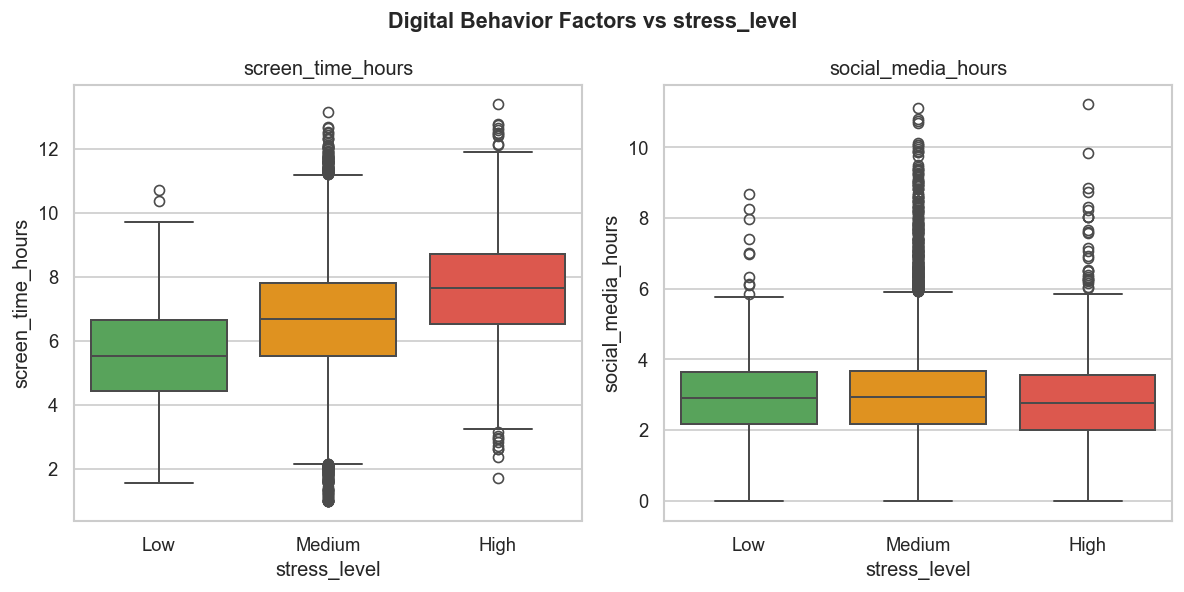

In [11]:
# 4.4 Kelompok Analisis: Digital Behavior Factors
digital_features = ['screen_time_hours', 'social_media_hours']

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Digital Behavior Factors vs stress_level', fontsize=13, fontweight='bold')

for i, col in enumerate(digital_features):
    sns.boxplot(data=daily_eda, x='stress_level', y=col, order=STRESS_ORDER,
                palette=STRESS_PALETTE, ax=axes[i], linewidth=1.2)
    axes[i].set_title(col)
    axes[i].set_xlabel('stress_level')

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / '06_digital_behavior_boxplot.png', bbox_inches='tight')
plt.show()

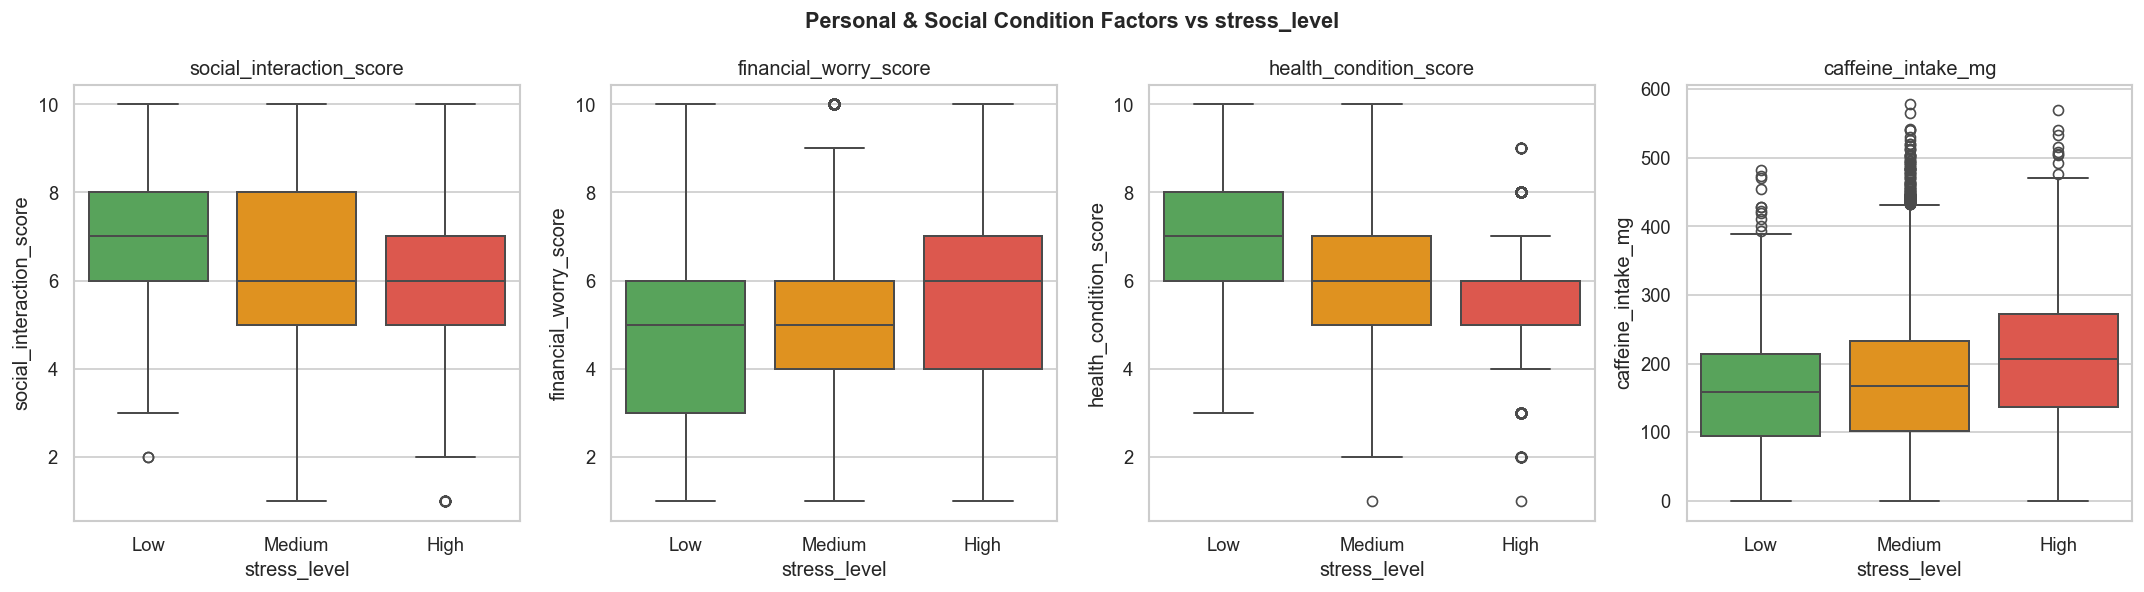

In [12]:
# 4.5 Kelompok Analisis: Personal/Social Condition Factors
personal_features = ['social_interaction_score', 'financial_worry_score', 'health_condition_score', 'caffeine_intake_mg']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Personal & Social Condition Factors vs stress_level', fontsize=13, fontweight='bold')

for i, col in enumerate(personal_features):
    sns.boxplot(data=daily_eda, x='stress_level', y=col, order=STRESS_ORDER,
                palette=STRESS_PALETTE, ax=axes[i], linewidth=1.2)
    axes[i].set_title(col)
    axes[i].set_xlabel('stress_level')

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / '07_personal_social_boxplot.png', bbox_inches='tight')
plt.show()

## Insight
- fatigue_level naik drastis dari Low (4.20) → Medium (5.94) → High (8.00). Kenaikan ini paling konsisten dan tajam di antara semua fitur, menjadikannya pembeda terkuat antar kelas.
- deadline_pressure juga naik tajam: Low (4.09) → Medium (6.24) → High (8.48). Bersama assignment_load (5.14 → 6.50 → 8.29), keduanya menunjukkan bahwa tekanan akademik adalah kelompok faktor risiko paling dominan.
- mood_score turun signifikan: Low (6.13) → Medium (4.48) → High (3.05). Ini pola protektif yang kuat, mahasiswa High stress rata-rata memiliki mood yang sangat rendah.
- sleep_hours turun dari Low (7.51) → Medium (6.92) → High (5.87). Mahasiswa High stress rata-rata tidur di bawah 6 jam, masuk ke zona risiko.
- social_media_hours hampir tidak berubah antar kelas (2.96 → 2.96 → 2.81), fitur ini tidak membedakan stress_level secara bermakna.
- caffeine_intake_mg naik dari Low (160) → High (205), tapi kenaikannya relatif kecil dibanding fitur lain.

# 5. Korelasi Fitur Numerik terhadap `stress_score`

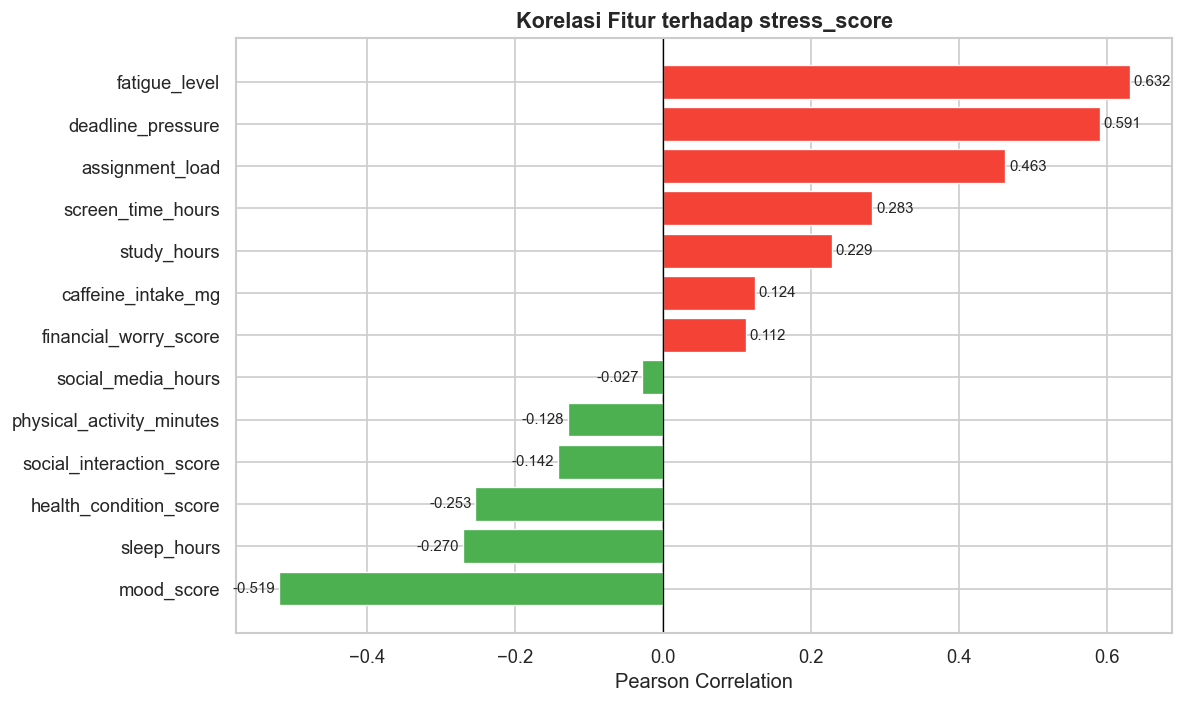

Saved: daily_feature_correlation_with_stress_score.csv


,feature,correlation_with_stress_score
12,fatigue_level,0.631518
11,deadline_pressure,0.591061
10,assignment_load,0.463017
9,screen_time_hours,0.283315
8,study_hours,0.228776
7,caffeine_intake_mg,0.124400
6,financial_worry_score,0.112064
5,social_media_hours,-0.027276
4,physical_activity_minutes,-0.128482
3,social_interaction_score,-0.141561


In [13]:
# 5.1 Correlation ranking
corr_with_score = daily_eda[FEATURE_COLS + ['stress_score']].corr()['stress_score'].drop('stress_score').sort_values()

colors = ['#F44336' if v > 0 else '#4CAF50' for v in corr_with_score.values]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(corr_with_score.index, corr_with_score.values, color=colors, edgecolor='white', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Korelasi Fitur terhadap stress_score', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
for bar, val in zip(bars, corr_with_score.values):
    offset = 0.005 if val >= 0 else -0.005
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', ha=ha, fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / '08_feature_correlation_ranking.png', bbox_inches='tight')
plt.show()

# Simpan ke CSV
corr_df = corr_with_score.reset_index()
corr_df.columns = ['feature', 'correlation_with_stress_score']
corr_df.to_csv(OUTPUT_REPORTS / 'daily_feature_correlation_with_stress_score.csv', index=False)
print('Saved: daily_feature_correlation_with_stress_score.csv')
corr_df.sort_values('correlation_with_stress_score', ascending=False)

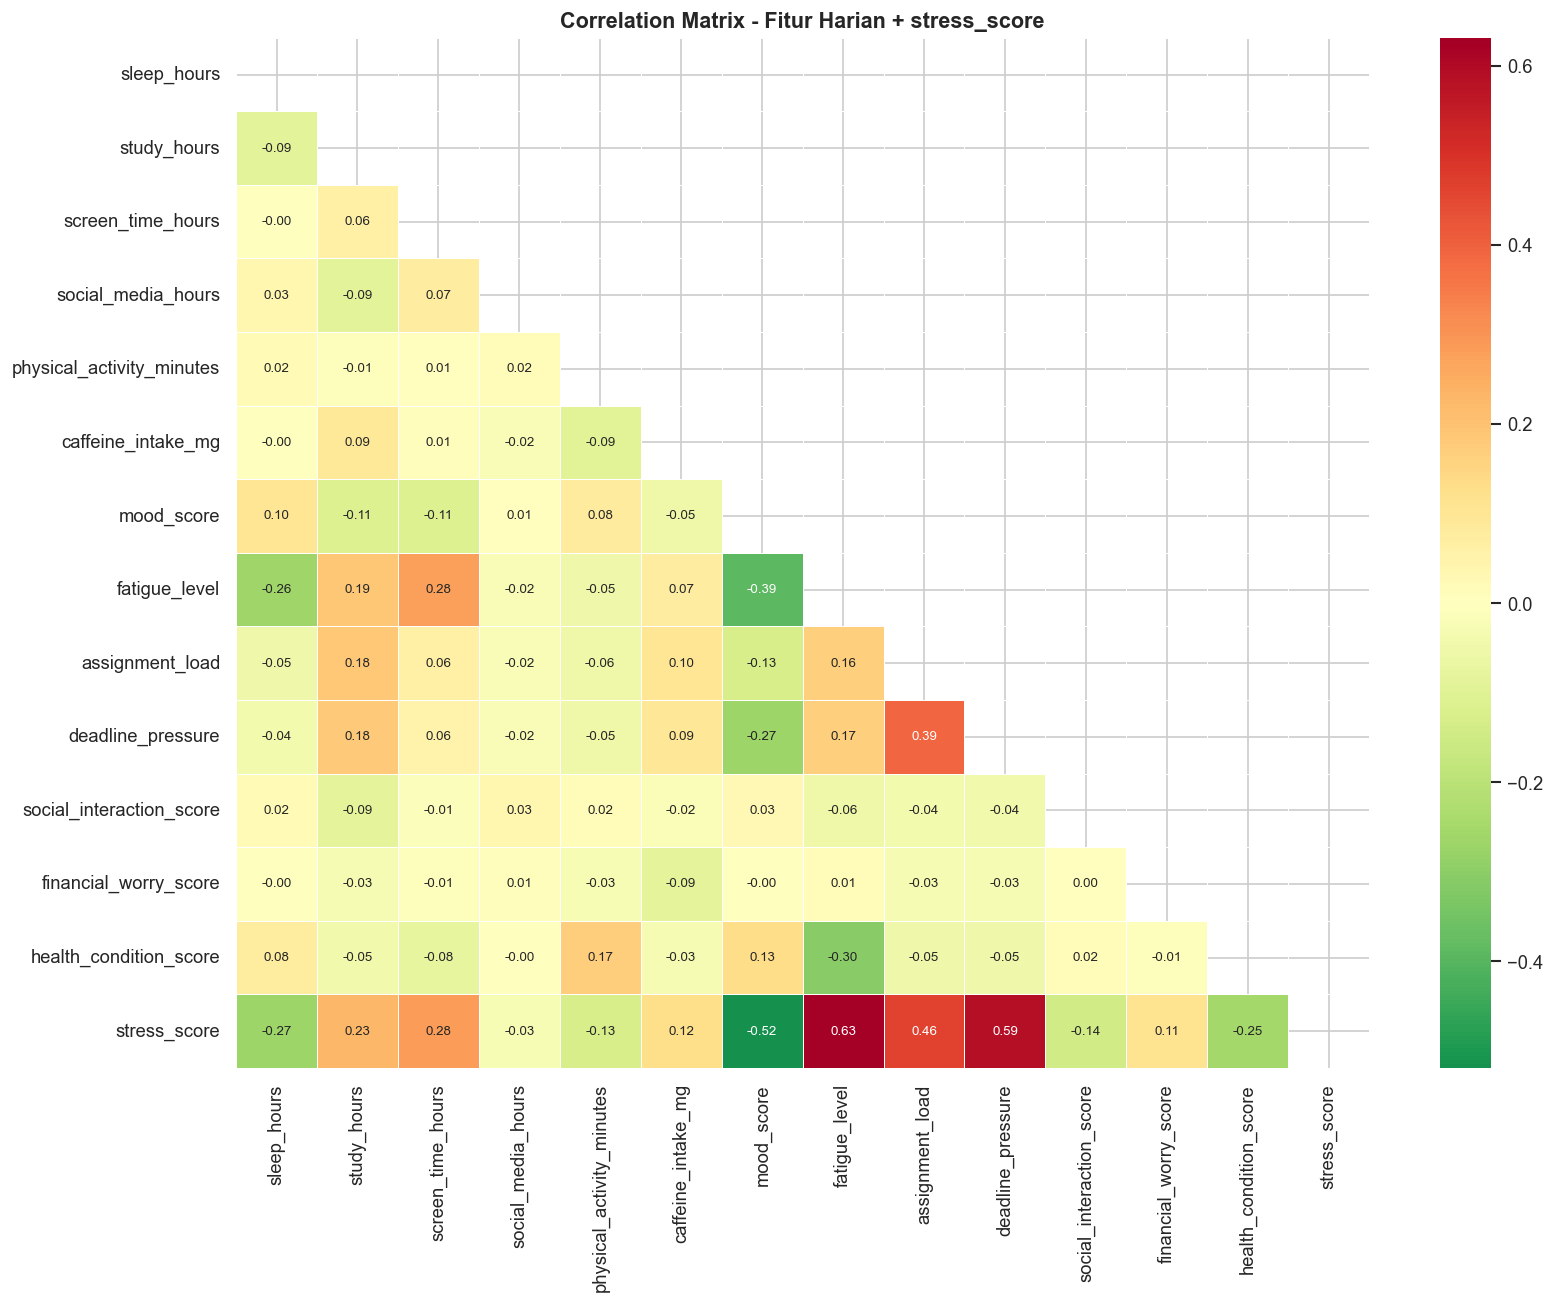

In [14]:
# 5.2 Correlation Matrix / Heatmap
corr_matrix = daily_eda[FEATURE_COLS + ['stress_score']].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Matrix - Fitur Harian + stress_score', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / '09_correlation_matrix_heatmap.png', bbox_inches='tight')
plt.show()

## Insight
- fatigue_level memiliki korelasi positif tertinggi terhadap stress_score (r = 0.632), diikuti deadline_pressure (r = 0.591) dan assignment_load (r = 0.463). Ketiganya adalah fitur paling penting untuk modelling.
- mood_score memiliki korelasi negatif terkuat (r = -0.519), mengonfirmasi bahwa mood rendah adalah sinyal stres tinggi yang paling konsisten.
- sleep_hours berkorelasi negatif cukup kuat (r = -0.270), tidur kurang = stres lebih tinggi, sesuai ekspektasi.
- social_media_hours hampir tidak berkorelasi (r = -0.027), ini konsisten dengan pola di Section 4 yang menunjukkan fitur ini tidak membedakan kelas.
- health_condition_score (r = -0.253) dan social_interaction_score (r = -0.142) berkorelasi negatif lemah, semakin sehat dan semakin aktif bersosialisasi, stres cenderung lebih rendah, tapi efeknya tidak sebesar fatigue atau mood.
- Catatan multikolinearitas: deadline_pressure dan assignment_load kemungkinan berkorelasi satu sama lain, ini mendukung rencana penggabungan ke academic_pressure_index di feature engineering.

# 6. HeatMap Kombinasi Fitur 

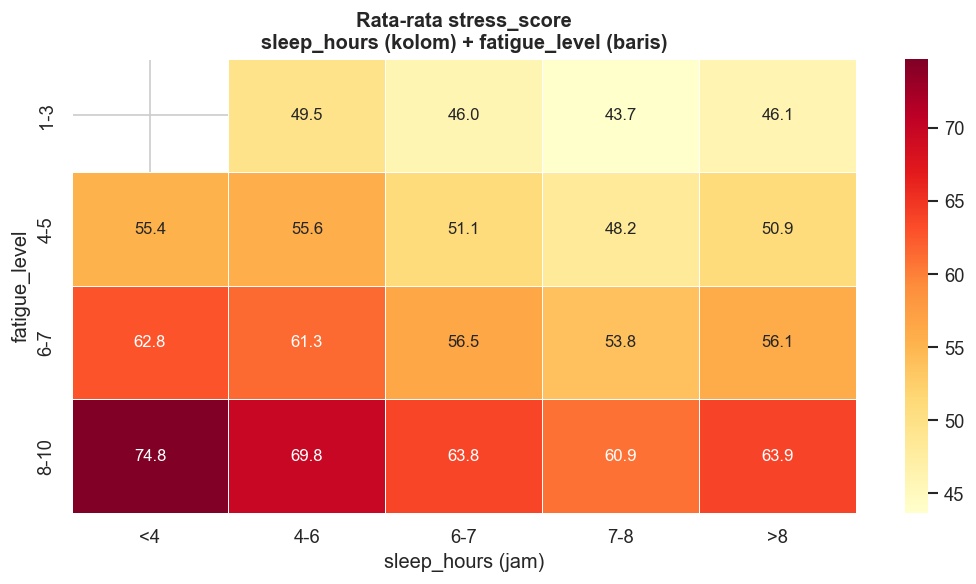

In [15]:
# --- 6.1 Heatmap: sleep_hours + fatigue_level ---
# Bin kedua kolom untuk membentuk matrix
df_combo = daily_eda.copy()
df_combo['sleep_bin'] = pd.cut(df_combo['sleep_hours'],
                                bins=[0, 4, 6, 7, 8, 24],
                                labels=['<4', '4-6', '6-7', '7-8', '>8'])
df_combo['fatigue_bin'] = pd.cut(df_combo['fatigue_level'],
                                  bins=[0, 3, 5, 7, 10],
                                  labels=['1-3', '4-5', '6-7', '8-10'])

pivot_sleep_fatigue = df_combo.pivot_table(
    values='stress_score', index='fatigue_bin', columns='sleep_bin', aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot_sleep_fatigue, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, annot_kws={'size': 10})
ax.set_title('Rata-rata stress_score\nsleep_hours (kolom) + fatigue_level (baris)', fontsize=12, fontweight='bold')
ax.set_xlabel('sleep_hours (jam)')
ax.set_ylabel('fatigue_level')

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / '10_heatmap_sleep_fatigue.png', bbox_inches='tight')
plt.show()

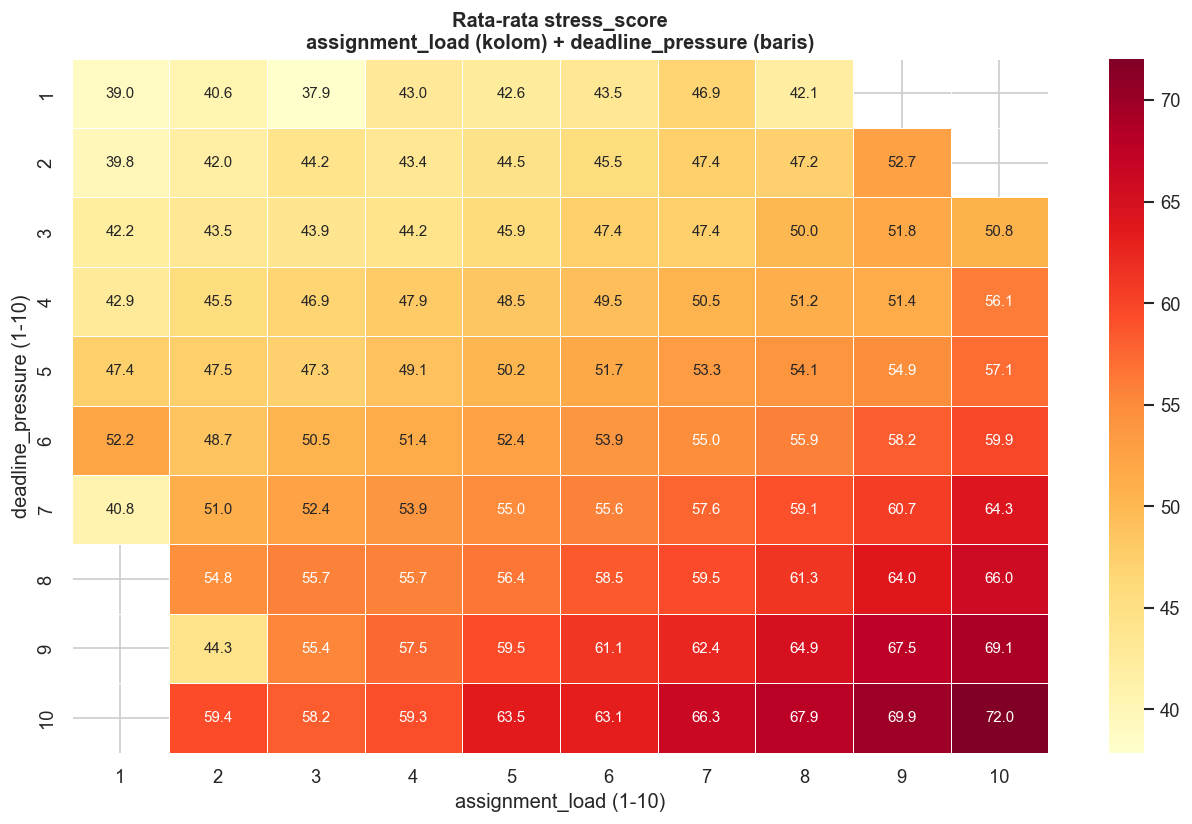

In [16]:
# --- 6.2 Heatmap: assignment_load + deadline_pressure ---
pivot_academic = daily_eda.pivot_table(
    values='stress_score',
    index='deadline_pressure',
    columns='assignment_load',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(pivot_academic, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Rata-rata stress_score\nassignment_load (kolom) + deadline_pressure (baris)', fontsize=12, fontweight='bold')
ax.set_xlabel('assignment_load (1-10)')
ax.set_ylabel('deadline_pressure (1-10)')

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / '11_heatmap_assignment_deadline.png', bbox_inches='tight')
plt.show()

## Insight
- Heatmap sleep + fatigue mengonfirmasi sinergi dua faktor recovery: kombinasi sleep rendah (<4 jam) dan fatigue tinggi (8-10) menghasilkan stress_score rata-rata tertinggi. Sebaliknya, sleep 7-8 jam dengan fatigue rendah (1-3) menghasilkan stress_score paling rendah.
- Tidur cukup (7-8 jam) mampu meredam dampak fatigue sedang (4-7) — ini mendukung rencana feature engineering recovery_index yang menggabungkan kedua fitur ini.
- Heatmap assignment_load + deadline_pressure menunjukkan gradasi yang sangat jelas dari kiri-bawah ke kanan-atas. Kombinasi assignment_load tinggi (9-10) dan deadline_pressure tinggi (9-10) secara konsisten menghasilkan stress_score tertinggi.
- Gradasi yang bersih di kedua heatmap ini memvalidasi bahwa data sintetis berhasil mengenkode hubungan antar fitur sesuai rule yang didesain.

# 7. Feature Importance Model Baseline

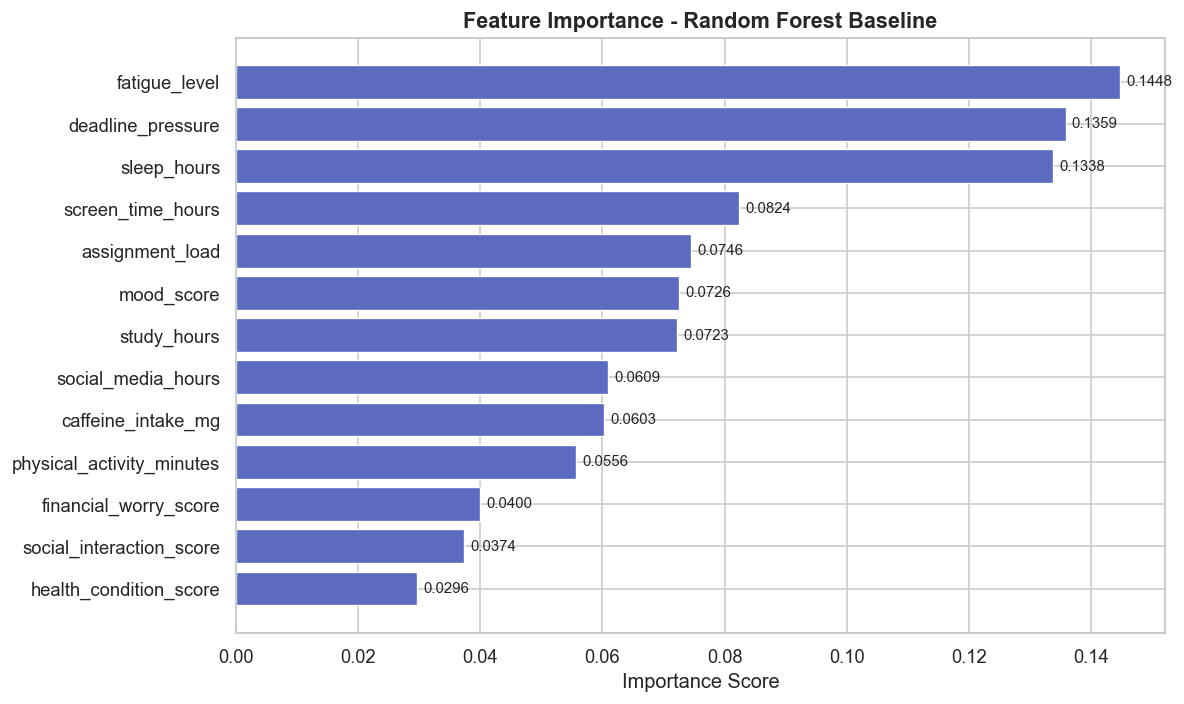

Saved: daily_feature_importance_baseline.csv

Class mapping: {'Low': 0, 'Medium': 1, 'High': 2}


,feature,importance
7,fatigue_level,0.144811
9,deadline_pressure,0.135853
0,sleep_hours,0.133778
2,screen_time_hours,0.082408
8,assignment_load,0.074568
6,mood_score,0.072561
1,study_hours,0.072256
3,social_media_hours,0.060881
5,caffeine_intake_mg,0.060259
4,physical_activity_minutes,0.055641


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

X = daily_eda[FEATURE_COLS].copy()
level_map = {'Low': 0, 'Medium': 1, 'High': 2}
y = daily_eda['stress_level'].map(level_map)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importance_df['feature'], importance_df['importance'],
               color='#5C6BC0', edgecolor='white', linewidth=0.8)
ax.set_title('Feature Importance - Random Forest Baseline', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
for bar, val in zip(bars, importance_df['importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='left', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / '12_feature_importance_baseline.png', bbox_inches='tight')
plt.show()

# Simpan
importance_df.sort_values('importance', ascending=False).to_csv(
    OUTPUT_REPORTS / 'daily_feature_importance_baseline.csv', index=False
)
print('Saved: daily_feature_importance_baseline.csv')
print(f'\nClass mapping: {level_map}')
importance_df.sort_values('importance', ascending=False)

## Insight
- Tiga fitur teratas RF: fatigue_level (0.1448), deadline_pressure (0.1359), dan sleep_hours (0.1338), menarik bahwa sleep_hours masuk top 3 di RF meski korelasinya (r = -0.270) tidak setinggi assignment_load (r = 0.463). Ini menunjukkan sleep_hours memiliki kemampuan pemisahan kelas yang kuat secara non-linear.
- mood_score di RF (importance 0.0726) lebih rendah dari ekspektasi berdasarkan korelasi (r = -0.519). Kemungkinan karena mood_score berkorelasi tinggi dengan fatigue_level sehingga RF sudah menangkap informasinya lewat fatigue.
- social_media_hours (0.0609) dan caffeine_intake_mg (0.0603) memiliki importance yang hampir sama dan cukup rendah, konsisten dengan korelasi yang lemah. Keduanya kandidat untuk diubah ke bentuk kategori atau digabung ke index.
- health_condition_score memiliki importance paling rendah (0.0296), fitur ini paling lemah secara prediktif dan perlu dievaluasi di notebook 04 apakah perlu dipertahankan atau dikeluarkan.

# 8. Trigger Dominan pada High Stress

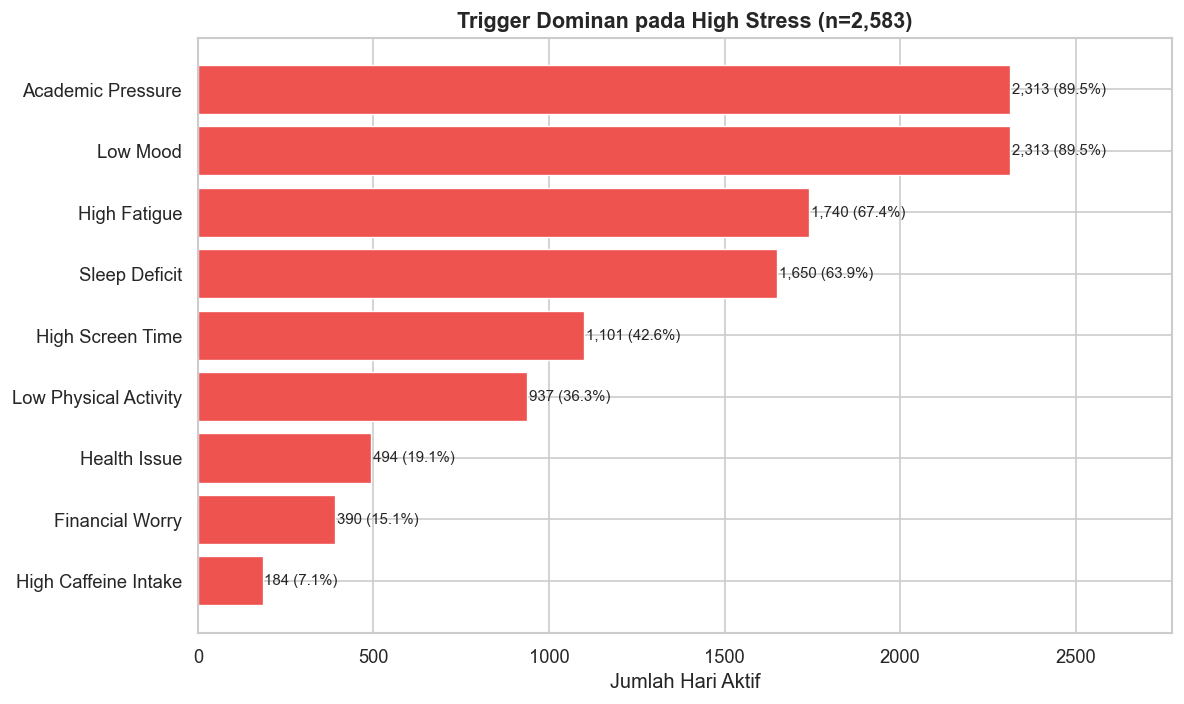


--- Trigger Counts pada High Stress ---
Low Mood                 : 2,313 hari (89.5%)
Academic Pressure        : 2,313 hari (89.5%)
High Fatigue             : 1,740 hari (67.4%)
Sleep Deficit            : 1,650 hari (63.9%)
High Screen Time         : 1,101 hari (42.6%)
Low Physical Activity    :   937 hari (36.3%)
Health Issue             :   494 hari (19.1%)
Financial Worry          :   390 hari (15.1%)
High Caffeine Intake     :   184 hari (7.1%)


In [18]:
high_stress = daily_eda[daily_eda['stress_level'] == 'High'].copy()

# Hitung trigger berdasarkan rule di dokumen (bagian 7)
triggers = {
    'Sleep Deficit'        : (high_stress['sleep_hours'] < 6),
    'Academic Pressure'    : (high_stress['deadline_pressure'] >= 8) | (high_stress['assignment_load'] >= 8),
    'High Fatigue'         : (high_stress['fatigue_level'] >= 8),
    'Low Mood'             : (high_stress['mood_score'] <= 4),
    'High Screen Time'     : (high_stress['screen_time_hours'] >= 8),
    'Low Physical Activity': (high_stress['physical_activity_minutes'] < 15),
    'Financial Worry'      : (high_stress['financial_worry_score'] >= 8),
    'Health Issue'         : (high_stress['health_condition_score'] <= 4),
    'High Caffeine Intake' : (high_stress['caffeine_intake_mg'] > 350),
}

trigger_counts = pd.Series({k: v.sum() for k, v in triggers.items()}).sort_values(ascending=True)
trigger_pct = (trigger_counts / len(high_stress) * 100).round(1)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(trigger_counts.index, trigger_counts.values,
               color='#EF5350', edgecolor='white', linewidth=0.8)
ax.set_title(f'Trigger Dominan pada High Stress (n={len(high_stress):,})', fontsize=13, fontweight='bold')
ax.set_xlabel('Jumlah Hari Aktif')
for bar, cnt, pct in zip(bars, trigger_counts.values, trigger_pct.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{cnt:,} ({pct}%)', va='center', ha='left', fontsize=9)
ax.set_xlim(0, trigger_counts.max() * 1.2)

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / '13_trigger_dominan_high_stress.png', bbox_inches='tight')
plt.show()

print('\n--- Trigger Counts pada High Stress ---')
for t in trigger_counts.sort_values(ascending=False).index:
    print(f'{t:25s}: {trigger_counts[t]:5,} hari ({trigger_pct[t]}%)')

## Insight
- Low Mood dan Academic Pressure sama-sama menjadi trigger paling dominan pada High stress, masing-masing aktif di 89.5% hari High stress (2.313 hari). Ini mengonfirmasi bahwa hampir tidak ada hari High stress tanpa salah satu dari dua kondisi ini.
- High Fatigue aktif di 67.4% hari High stress, dan Sleep Deficit di 63.9%, keduanya sering muncul bersamaan, memperkuat argumen untuk recovery_index sebagai fitur gabungan.
- High Screen Time (42.6%) dan Low Physical Activity (36.3%) berada di tier menengah, cukup sering tapi bukan trigger utama.
- Financial Worry (15.1%) dan High Caffeine Intake (7.1%) adalah trigger paling jarang, konsisten dengan bobot kecil keduanya di rule sintesis (6% dan 2%).

# 9. Save Output

In [19]:
# Simpan daily_eda_dataset.csv
daily_eda.to_csv(DATA_PROCESSED / 'daily_eda_dataset.csv', index=False)
print('Saved: daily_eda_dataset.csv')

# Simpan feature summary by stress_level
summary_df = daily_eda.groupby('stress_level')[FEATURE_COLS].agg(['mean', 'median', 'std']).round(3)
summary_df.to_csv(OUTPUT_REPORTS / 'daily_feature_summary_by_stress_level.csv')
print('Saved: daily_feature_summary_by_stress_level.csv')

print('\n--- Semua output telah disimpan ---')
print(f'  data/processed/daily_eda_dataset.csv')
print(f'  outputs/reports/daily_feature_correlation_with_stress_score.csv')
print(f'  outputs/reports/daily_feature_summary_by_stress_level.csv')
print(f'  outputs/reports/daily_feature_importance_baseline.csv')
print(f'  outputs/figures/eda/ (13 grafik)')

Saved: daily_eda_dataset.csv
Saved: daily_feature_summary_by_stress_level.csv

--- Semua output telah disimpan ---
  data/processed/daily_eda_dataset.csv
  outputs/reports/daily_feature_correlation_with_stress_score.csv
  outputs/reports/daily_feature_summary_by_stress_level.csv
  outputs/reports/daily_feature_importance_baseline.csv
  outputs/figures/eda/ (13 grafik)


# 10. Conclusion
- Dataset sangat imbalanced (Medium 87.5%, High 9.7%, Low 2.8%), ini harus ditangani sebelum modelling dengan class_weight='balanced' atau resampling. Jangan gunakan accuracy sebagai metrik utama.

- Fitur terkuat berdasarkan korelasi dan RF importance: fatigue_level, deadline_pressure, sleep_hours, mood_score, dan assignment_load. Kelimanya harus dipertahankan di modelling dataset.

- social_media_hours hampir tidak memiliki hubungan dengan stress_score (r = -0.027, importance 0.061), pertimbangkan untuk tidak memasukkannya sebagai fitur mandiri, atau ubah ke rasio terhadap screen_time_hours (social_media_ratio).

- health_condition_score adalah fitur prediktif paling lemah (importance 0.030), evaluasi ulang di notebook 04 apakah perlu dipertahankan.

- Kandidat feature engineering yang terdukung data: academic_pressure_index (deadline_pressure + assignment_load berkorelasi tinggi satu sama lain), recovery_index (sleep_hours + fatigue_level sinergi kuat di heatmap), social_media_ratio (social_media_hours hampir tidak informatif secara mandiri).

- Tidak ada data leakage: stress_score tidak masuk FEATURE_COLS, semua kolom teknis tidak digunakan sebagai fitur.

- Semua output telah tersimpan dan siap digunakan sebagai referensi di 04_eda_summary_and_feature_engineering_plan.ipynb.

## Jawaban Business Question

**BQ Utama:**
> Faktor aktivitas harian apa saja yang paling berkaitan dengan stress_level dan stress_score mahasiswa?

Berdasarkan hasil EDA, faktor yang paling berkaitan adalah `fatigue_level` (r = 0.632), `deadline_pressure` (r = 0.591), `mood_score` (r = -0.519), `sleep_hours` (r = -0.270), dan `assignment_load` (r = 0.463). Kelima fitur ini juga mendominasi feature importance RF baseline, mengonfirmasi bahwa kelelahan dan tekanan akademik adalah kelompok faktor risiko utama, sementara mood dan tidur adalah faktor protektif terkuat.

---

- **Sub-BQ 1: Apakah mahasiswa dengan jam tidur rendah cenderung memiliki stress_score lebih tinggi?**
    a. Rata-rata sleep_hours turun konsisten dari Low (7.51 jam) → Medium (6.92 jam) → High (5.87 jam). Mahasiswa High stress rata-rata tidur di bawah 6 jam, masuk zona risiko. Korelasi negatif r = -0.270 mengonfirmasi hubungan ini.

- **Sub-BQ 2: Bagaimana hubungan antara assignment_load dan deadline_pressure terhadap stress_level?**
    eduanya naik tajam seiring stress_level. assignment_load: Low (5.14) → High (8.29). deadline_pressure: Low (4.09) → High (8.48). Heatmap kombinasi menunjukkan gradasi yang sangat jelas, semakin tinggi keduanya secara bersamaan, semakin tinggi stress_score. Keduanya adalah kelompok faktor risiko akademik paling dominan.

- **Sub-BQ 3: Apakah screen_time_hours dan social_media_hours berkaitan dengan peningkatan stres?**
    Sebagian. screen_time_hours memiliki korelasi positif moderat (r = 0.283) dan rata-ratanya naik dari Low (5.54) → High (7.61 jam). Sebaliknya, social_media_hours hampir tidak berkorelasi (r = -0.027) dan rata-ratanya tidak berubah antar kelas — fitur ini tidak membedakan stress_level secara bermakna.

- **Sub-BQ 4: Faktor recovery apa yang paling membantu menurunkan tingkat stres mahasiswa?**
    mood_score adalah faktor protektif terkuat (r = -0.519), diikuti sleep_hours (r = -0.270). physical_activity_minutes juga berpengaruh, rata-ratanya turun dari Low (31.20 menit) → High (22.65 menit), meski korelasinya lebih lemah (r = -0.128). Kombinasi sleep rendah dan fatigue tinggi terbukti menghasilkan stress_score tertinggi berdasarkan heatmap.

- **Sub-BQ 5: Apakah fatigue_level dan mood_score memiliki hubungan kuat terhadap stress_score?**
    Ya, keduanya adalah fitur dengan hubungan terkuat. fatigue_level memiliki korelasi positif tertinggi (r = 0.632) dan feature importance tertinggi di RF (0.1448). mood_score memiliki korelasi negatif terkuat (r = -0.519). Rata-rata fatigue_level pada High stress mencapai 8.0 dari skala 10, sementara mood_score hanya 3.05.

- **Sub-BQ 6: Faktor sosial dan kondisi personal apa yang paling sering muncul pada mahasiswa dengan stres tinggi?**
    financial_worry_score naik dari Low (4.68) → High (5.50), sementara social_interaction_score dan health_condition_score justru turun pada High stress. Dari sisi trigger, Low Mood dan Academic Pressure aktif di 89.5% hari High stress,  menjadikannya trigger paling dominan. Financial Worry hanya aktif di 15.1% hari High stress, menjadikannya faktor sosial dengan pengaruh paling lemah.